# Resolución problema MMM a partir de su matriz QUBO

In [41]:
#pip install pulser pulser-simulation
from bloqade.analog import start, cast, load, save
import os
import matplotlib.pyplot as plt
from bokeh.io import output_notebook
from bloqade.analog.atom_arrangement import ListOfLocations, Square
from bloqade.analog import piecewise_linear, cast
from bloqade.analog.atom_arrangement import ListOfLocations, Lieb, Square, Chain, Honeycomb, Kagome, Triangular, Rectangular
import numpy as np
from IPython.display import display, HTML
from bokeh.io import output_notebook
output_notebook()

import matplotlib.pyplot as plt
import pulser
import pulser_simulation
from scipy.optimize import minimize
from scipy.spatial.distance import pdist, squareform
import matplotlib.colors as mcolors
import time


Loading BokehJS ...

# Definición de funciones para la resolución del grafo
1. `resolucion_clasica`: Obtiene la solución a lo bruto de forma clásica
2. `construir_geometria`: Establece la geometrías que codifica la matriz QUBO dada. Usa el algoritmo clásico Nelder-Mead
3. `resolver_qubo`: Emula el ordenador cuántico aportando la solución

In [42]:
    # Obtenemos la solución clásica por fuerza bruta
    def resolucion_clasica(Q_exacta, print_resultados = False):
        """
        Resuelve un problema QUBO por fuerza bruta (enumeración exhaustiva).

        Parámetros
        ----------
        Q       : array-like – Matriz QUBO.
        verbose : bool       – Si True, imprime las mejores soluciones.

        Retorna
        -------
        sort_zipped : list[(str, float)] – Todos los bitstrings ordenados por coste.
        """
        Q_exacta = np.array(Q_exacta)

        bitstrings = [np.binary_repr(i, len(Q_exacta)) for i in range(2 ** len(Q_exacta))]
        costs = []
        # this takes exponential time with the dimension of the QUBO
        for b in bitstrings:
            z = np.array(list(b), dtype=int)
            cost = z @ Q_exacta @ z
            costs.append(cost)
        zipped = zip(bitstrings, costs)
        sort_zipped = sorted(zipped, key=lambda x: x[1])

        if print_resultados:
            print(f"---Solución clásica: \n {sort_zipped[:6]} \n")

        return sort_zipped
    # Ejecución de la función 
    #sort_zipped = resolucion_clasica(Q_exacta)


    # Determinamos la geometría de los átomos para Q
    def construir_geometria(Q, seed=0, tol=1e-6, maxiter=200000, plot=False, x0_func=None):
        """
        Optimiza las coordenadas atómicas para que las interacciones Rydberg
        reproduzcan la matriz QUBO, y construye la geometría de Bloqade.

        Parámetros
        ----------
        Q       : array-like – Matriz QUBO (simétrica).
        seed    : int        – Semilla para reproducibilidad.
        tol     : float      – Tolerancia del optimizador Nelder-Mead.
        maxiter : int        – Máximo de iteraciones.
        plot    : bool       – Si True, dibuja el registro Pulser y la geometría Bloqade.

        Retorna
        -------
        geometria : bloqade Program – Geometría lista para montar el programa.
        coords    : np.ndarray      – Coordenadas optimizadas (n×2).
        """
        Q = np.array(Q)
        device = pulser.DigitalAnalogDevice

        def evaluate_mapping(new_coords):
            new_coords = np.reshape(new_coords, (len(Q), 2))
            new_Q = squareform(device.interaction_coeff / pdist(new_coords) ** 6)
            return np.linalg.norm(new_Q - Q)

        # Por si queremos cambiar el x0:
        if x0_func is not None:
            x0 = x0_func(A, Q)
        else:
            np.random.seed(seed)
            x0 = np.random.random(len(Q) * 2)

        #if random_x0 == True:
        #    np.random.seed(seed)
        #    x0 = np.random.random(len(Q) * 2)
        #elif random_x0 == False:
        #    C6 = 2 * np.pi * 862690
        #    d_init = (C6 / A) ** (1/6)
        #    x0 = np.array([[i * d_init, 0.0] for i in range(len(Q))]).flatten() #Esto es para colocar los átomos en línea, con la distancia inicial d_init

        res = minimize(
            evaluate_mapping,
            x0,
            method="Nelder-Mead",
            tol=tol,
            options={"maxiter": maxiter, "maxfev": None},
        )

        coords = np.reshape(res.x, (len(Q), 2))

        if plot:
            # Visualización Pulser
            #coord_dict = {f"q{i}": coord for i, coord in enumerate(coords)}
            #reg = pulser.Register(coord_dict)
            #reg.draw(
            #    blockade_radius=device.rydberg_blockade_radius(1),
            #    draw_graph=False,
            #    draw_half_radius=True,
            #)
            coord_dict = {f"e{i}": coord for i, coord in enumerate(coords)}
            reg = pulser.Register(coord_dict)
            # Radio de bloqueo operativo: el omega_max que se usa en resolver_qubo
            omega_max = 0.9 * np.min(-np.diag(Q))
            reg.draw(
                blockade_radius=device.rydberg_blockade_radius(omega_max),
                draw_graph=False,
                draw_half_radius=True,
            )
            print(f"Coordenadas optimizadas:\n{coords}")

        # Construcción Bloqade
        coordenadas = [tuple(pt) for pt in coords.tolist()]
        geometria = start.add_position(coordenadas)

        if plot:
            geometria.show()

        return geometria, coords
    # Ejecución de la función 
    #geometria, coords = construir_geometria(Q)


    def resolver_qubo(Q, geometria, sort_zipped, A, B, C,
                        sweep_time=11.0, plot=False, n_shots=1000):
        """
        Ejecuta la simulación de átomos neutros para un problema QUBO dado.

        Parámetros
        ----------
        Q             : array-like  – Matriz QUBO.
        geometria     : Register     – Geometría de átomos (Bloqade).
        sort_zipped   : list[(str, float)] – Soluciones clásicas ordenadas (bitstring, energía).
        A, B, C       : float        – Coeficientes QUBO (solo para etiquetas).
        omega_max     : float        – Amplitud máxima de la frecuencia de Rabi.
        sweep_time    : float        – Tiempo de evolución adiabática [µs].
        plot          : bool         – Si True, muestra el histograma.
        n_shots       : int          – Número de disparos de la simulación.
        sweep_time    : float        – Tiempo de evolución adiabática [µs].
        plot          : bool         – Si True, muestra el histograma.

        Retorna
        -------
        prob_exito    : float        – Probabilidad de medir la solución correcta.
        counts_str    : dict         – {bitstring: conteos}.
        """
        # ── PASO 1: Detunings locales desde la diagonal de Q ──
        Q = np.array(Q)
        delta_local = -np.diag(Q)
        delta_end   = np.max(delta_local)
        escalas     = (delta_local / delta_end).tolist()

        # ── PASO 2: Parámetros de pulso ──
        omega_max = 0.9 * np.min(np.abs(delta_local))
        sweep_time= sweep_time
        durations             = [0.8, sweep_time, 0.8]
        rabi_amplitude_values = [0.0, omega_max, omega_max, 0.0]
        rabi_detuning_values  = [-delta_end, -delta_end, delta_end, delta_end]

        # ── PASO 3: Simulación ──
        prog = (
            geometria
            .rydberg.rabi.amplitude.uniform.piecewise_linear(durations, rabi_amplitude_values)
            .detuning.scale(escalas).piecewise_linear(durations, rabi_detuning_values)
        )
        emu_prog = prog.bloqade.python().run(shots=n_shots)
        report   = emu_prog.report()
        if plot:
            report.show()


        # ── PASO 4: Análisis ──
        counts = report.counts()[0]
        counts_str = {
            "".join(str(b) for b in estado): n
            for estado, n in counts.items()
        }

        energia_minima   = sort_zipped[0][1]
        soluciones_validas = [b for b, e in sort_zipped if e == energia_minima]

        exitos     = sum(counts_str.get(s, 0) for s in soluciones_validas)
        prob_exito = exitos / n_shots

        # ── PASO 5: Resultados ──
        if plot:
            print(f"A={A}, B={B}, C={C}  →  P(éxito) = {prob_exito*100:.2f}%")
            print(f"  Soluciones válidas: {soluciones_validas}  (E = {energia_minima:.3f})")
            print(f"  Conteos solución:   {exitos} / {n_shots}")
            counts_ordenado = dict(sorted(counts_str.items(), key=lambda x: x[1], reverse=True))
            colores = ["r" if b in soluciones_validas else "steelblue" for b in counts_ordenado]
            plt.figure(figsize=(12, 5))
            plt.bar(counts_ordenado.keys(), counts_ordenado.values(), color=colores, width=0.5)
            plt.xlabel("Bitstrings")
            plt.ylabel("Conteos")
            plt.title(f"A={A}, B={B}, C={C}  →  P(éxito) = {prob_exito*100:.2f}%")
            plt.xticks(rotation=90, fontsize=7)
            plt.tight_layout()
            plt.show()

        return prob_exito, counts_str
    # Ejecución de la función 
    #prob, counts = resolver_qubo(Q, geometria, sort_zipped, A, B, C)

## Generar gráficas señales para el informe

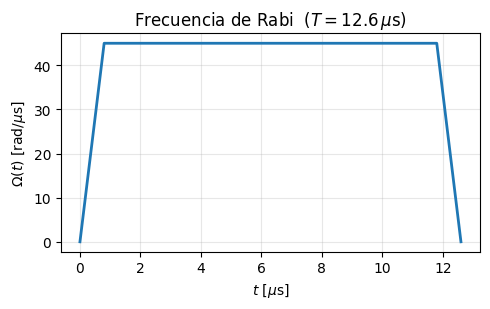

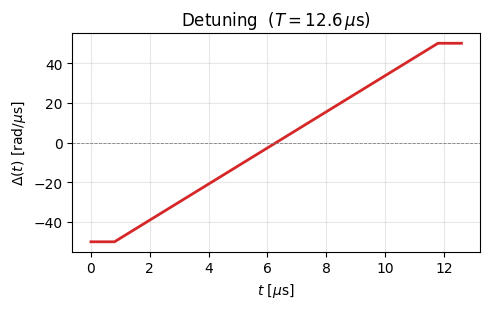

In [16]:
import numpy as np
import matplotlib.pyplot as plt

# --- Parámetros del pulso ---
sweep_time = 11.0          # µs, duración del tramo central
durations = [0.8, sweep_time, 0.8]
T_total = sum(durations)   # duración total del pulso

# Valores de ejemplo (rad/µs); ajusta si quieres reflejar otro caso
delta_end  = 50.0
omega_max  = 0.9 * delta_end

rabi_amplitude_values = [0.0, omega_max, omega_max, 0.0]
rabi_detuning_values  = [-delta_end, -delta_end, delta_end, delta_end]

# Eje temporal acumulado
t = np.concatenate(([0.0], np.cumsum(durations)))

# --- Figura 1: Frecuencia de Rabi ---
fig1, ax1 = plt.subplots(figsize=(5, 3.2))
ax1.plot(t, rabi_amplitude_values, color="tab:blue", lw=2)
ax1.set_xlabel(r"$t$ [$\mu$s]")
ax1.set_ylabel(r"$\Omega(t)$ [rad/$\mu$s]")
ax1.set_title(rf"Frecuencia de Rabi  ($T = {T_total:.1f}\,\mu$s)")
ax1.grid(alpha=0.3)
fig1.tight_layout()
fig1.savefig("pulso_rabi.png", dpi=200, bbox_inches="tight")
plt.show()

# --- Figura 2: Detuning ---
fig2, ax2 = plt.subplots(figsize=(5, 3.2))
ax2.plot(t, rabi_detuning_values, color="tab:red", lw=2)
ax2.set_xlabel(r"$t$ [$\mu$s]")
ax2.set_ylabel(r"$\Delta(t)$ [rad/$\mu$s]")
ax2.set_title(rf"Detuning  ($T = {T_total:.1f}\,\mu$s)")
ax2.axhline(0, color="gray", lw=0.6, ls="--")
ax2.grid(alpha=0.3)
fig2.tight_layout()
fig2.savefig("pulso_detuning.png", dpi=200, bbox_inches="tight")
plt.show()

# Definición del grafo (matriz Q)
Distingo entre `Q` y `Q_exacta` porque la interacción entre aristas separadas por más de un nodo a veces altera la resolución del problema

### $P_3$

In [81]:
#Grafo P_3 (cadena de 3 nodos, 2 aristas)

A_solucion=10
B_solucion=5
C_solucion=3

nombre_grafo = str("P3")

Q_func_P3 = lambda A, B, C: np.array([
    [-2*B+C, A+2*B],
    [0,      -2*B+C]
])
Q_func = Q_func_P3

Q_exacta_func_P3 = lambda A, B, C: np.array([
    [-2*B+C, A+2*B],
    [0,      -2*B+C]
])
Q_exacta_func = Q_exacta_func_P3

def x0_func_P3(A, Q):
    C6 = 2 * np.pi * 862690
    d = (C6 / A) ** (1/6)
    return np.array([[i * d, 0.0] for i in range(len(Q))]).flatten()

### Grafo $P_4$

In [84]:
#Grafo P_4 (cadena de 4 nodos)

A_solucion=10
B_solucion=5
C_solucion=3

nombre_grafo = str("P4")

Q_func_P4 = lambda A, B, C: np.array(
    [[-2*B+C, A+2*B, 0      ],
     [0,      -3*B+C, A+2*B ],
     [0,       0,     -2*B+C]]
)
Q_func = Q_func_P4

Q_exacta_func_P4 = lambda A, B, C: np.array([
    [-2*B+C, A+2*B, B],
    [0,      -3*B+C, A+2*B],
    [0,       0,     -2*B+C]
])
Q_exacta_func = Q_exacta_func_P4
# 
def x0_func_P4(A, Q):
    C6 = 2 * np.pi * 862690
    d = (C6 / A) ** (1/6)
    return np.array([[i * d, 0.0] for i in range(len(Q))]).flatten()


### $P_5$

In [86]:
A_solucion=50
B_solucion=0.8*A_solucion
C_solucion=0.5*A_solucion

nombre_grafo = str("P5")

Q_func_P5 = lambda A, B, C: np.array([
    [-2*B+C, A+2*B, 0,      0     ],
    [0,      -3*B+C, A+2*B, 0     ],
    [0,       0,    -3*B+C, A+2*B ],
    [0,       0,     0,    -2*B+C ]
])
Q_func = Q_func_P5

Q_exacta_func_P5 = lambda A, B, C: np.array([
    [-2*B+C, A+2*B, 0,      0     ],
    [0,      -3*B+C, A+2*B, 0     ],
    [0,       0,    -3*B+C, A+2*B ],
    [0,       0,     0,    -2*B+C ]
])
Q_exacta_func = Q_exacta_func_P5

def x0_func_P5(A, Q):
    C6 = 2 * np.pi * 862690
    d = (C6 / A) ** (1/6)
    return np.array([[i * d, 0.0] for i in range(len(Q))]).flatten()

### $P_5 \ modificado$ 

In [89]:
A_solucion=20
B_solucion=0.5*A_solucion
C_solucion=0.1*A_solucion

nombre_grafo = str("P5 modificado")

Q_func_P5mod = lambda A, B, C: np.array([
    [-2*B+C, A+2*B, 0,      0,      0     ],
    [0,      -4*B+C, A+2*B, 0,      A+2*B ],
    [0,       0,    -4*B+C, A+2*B,  A+2*B ],
    [0,       0,     0,    -2*B+C,  0     ],
    [0,       0,     0,     0,     -3*B+C ]
])
Q_func = Q_func_P5mod


Q_exacta_func_P5mod = lambda A, B, C: np.array([
    [-2*B+C, A+2*B, B,      0,      B     ],
    [0,      -4*B+C, A+2*B, B,      A+2*B ],
    [0,       0,    -4*B+C, A+2*B,  A+2*B ],
    [0,       0,     0,    -2*B+C,  B     ],
    [0,       0,     0,     0,     -3*B+C ]
])
Q_exacta_func = Q_exacta_func_P5mod


#C6 = 2 * np.pi * 862690
#d_init = (C6 / A) ** (1/6)

def x0_func_P5mod(A, Q):
    C6 = 2 * np.pi * 862690
    d = (C6 / A) ** (1/6)
    return np.array([
        [0 * d,   0.0],  # e0
        [1 * d,   0.0],  # e1
        [2 * d,   0.0],  # e2
        [3 * d,   0.0],  # e3
        [1.5 * d, d  ],  # e4
    ]).flatten()

### $P_6$

In [91]:
A_solucion=10
B_solucion=5
C_solucion=3

nombre_grafo = str("P6")

Q_func_P6 = lambda A, B, C: np.array([
    [-2*B+C, A+2*B, 0,      0,      0     ],
    [0,      -3*B+C, A+2*B, 0,      0     ],
    [0,       0,    -3*B+C, A+2*B,  0     ],
    [0,       0,     0,    -3*B+C,  A+2*B ],
    [0,       0,     0,     0,     -2*B+C ]
])
Q_func = Q_func_P6

Q_exacta_func_P6 = lambda A, B, C: np.array([
    [-2*B+C, A+2*B, B,      0,      0    ],
    [0,      -3*B+C, A+2*B, B,      0     ],
    [0,       0,    -3*B+C, A+2*B,  B     ],
    [0,       0,     0,    -3*B+C,  A+2*B ],
    [0,       0,     0,     0,     -2*B+C ]
])
Q_exacta_func = Q_exacta_func_P6


def x0_func_P6(A, Q):
    C6 = 2 * np.pi * 862690
    d = (C6 / A) ** (1/6)
    return np.array([
        [0 * d,   0.0],  # e0
        [1 * d,   0.0],  # e1
        [2 * d,   0.0],  # e2
        [3 * d,   0.0],  # e3
        [4 * d,   0.0],  # e4
    ]).flatten()

### $P_6 \ modificado$

In [95]:
A_solucion=10
B_solucion=5
C_solucion=3

nombre_grafo = str("P6 modificado")

Q_exacta_func_P6mod = lambda A, B, C: np.array([
    [-2*B+C, A+2*B, B,      0,      0,      0     ],
    [0,      -3*B+C, A+2*B, B,      0,      B     ],
    [0,       0,    -4*B+C, A+2*B,  B,      A+2*B ],
    [0,       0,     0,    -4*B+C,  A+2*B,  A+2*B ],
    [0,       0,     0,     0,     -2*B+C,  B     ],
    [0,       0,     0,     0,      0,     -3*B+C ]
])
Q_exacta_func = Q_exacta_func_P6mod

Q_func_P6mod = lambda A, B, C: np.array([
    [-2*B+C, A+2*B,  0,     0,      0,      0     ],
    [0,      -3*B+C, A+2*B, 0,      0,      0     ],
    [0,       0,    -4*B+C, A+2*B,  0,      A+2*B ],
    [0,       0,     0,    -4*B+C,  A+2*B,  A+2*B ],
    [0,       0,     0,     0,     -2*B+C,  0     ],
    [0,       0,     0,     0,      0,     -3*B+C ]
])
Q_exacta_func = Q_exacta_func_P6mod

def x0_func_P6mod(A, Q):
    C6 = 2 * np.pi * 862690
    d = (C6 / A) ** (1/6)
    return np.array([
        [0 * 2*d,    0.0],  # e0
        [1 * 2*d,    0.0],  # e1
        [2 * 2*d,    0.0],  # e2
        [3 * 2*d,    0.0],  # e3
        [4 * 2*d,    0.0],  # e4
        [2.5 * 2*d,  2*d  ],  # e5
    ]).flatten()



### Grafo $P_7$

In [66]:
A_solucion=50
B_solucion=15
C_solucion=5

nombre_grafo = str("P7")

Q_func_P7 = lambda A, B, C: np.array([
    [-2*B+C, A+2*B, 0,      0,      0,      0   ],
    [0,      -3*B+C, A+2*B, 0,      0,      0   ],
    [0,      0,     -3*B+C, A+2*B,  0,      0   ],
    [0,      0,     0,     -3*B+C, A+2*B,   0   ],
    [0,      0,     0,     0,     -3*B+C, A+2*B ],
    [0,      0,     0,     0,     0,     -2*B+C ]
])
Q_func = Q_func_P7

Q_exacta_func_P7 = lambda A, B, C: np.array([
    [-2*B+C, A+2*B, B,      0,      0,      0   ],
    [0,      -3*B+C, A+2*B, B,      0,      0   ],
    [0,      0,     -3*B+C, A+2*B,  B,      0   ],
    [0,      0,     0,     -3*B+C, A+2*B,  B   ],
    [0,      0,     0,     0,     -3*B+C, A+2*B ],
    [0,      0,     0,     0,     0,     -2*B+C ]
])
Q_exacta_func_P7 = lambda A, B, C: np.array([
    [-2*B+C, A+2*B, 0,      0,      0,      0   ],
    [0,      -3*B+C, A+2*B, 0,      0,      0   ],
    [0,      0,     -3*B+C, A+2*B,  0,      0   ],
    [0,      0,     0,     -3*B+C, A+2*B,  0   ],
    [0,      0,     0,     0,     -3*B+C, A+2*B ],
    [0,      0,     0,     0,     0,     -2*B+C ]
])
Q_exacta_func = Q_exacta_func_P7

def x0_func_P7(A, Q):
    C6 = 2 * np.pi * 862690
    d = (C6 / A) ** (1/6)
    return np.array([
        [0 * d,   0.0],  # e0
        [1 * d,   0.0],  # e1
        [2 * d,   0.0],  # e2
        [3 * d,   0.0],  # e3
        [4 * d,   0.0],  # e4
        [5 * d,   0.0],  # e5
    ]).flatten()

### Grafo $P_8$

In [48]:
A_solucion=50
B_solucion=15   
C_solucion=5


nombre_grafo = str("P8")

Q_func_P8 = lambda A, B, C: np.array([
    [-2*B+C, A+2*B, 0,      0,      0,      0,     0   ],
    [0,      -3*B+C, A+2*B, 0,      0,      0,     0   ],
    [0,      0,     -3*B+C, A+2*B, 0,      0,      0   ],
    [0,      0,     0,     -3*B+C, A+2*B, 0,       0   ],
    [0,      0,     0,     0,     -3*B+C, A+2*B,   0   ],
    [0,      0,     0,     0,     0,     -3*B+C, A+2*B ],
    [0,      0,     0,     0,     0,     0,     -2*B+C ]
])
Q_func = Q_func_P8

Q_exacta_func_P8 = lambda A, B, C: np.array([
    [-2*B+C, A+2*B, B,      0,      0,      0,      0  ],
    [0,      -3*B+C, A+2*B, B,      0,      0,      0  ],
    [0,      0,     -3*B+C, A+2*B, B,      0,       0  ],
    [0,      0,     0,     -3*B+C, A+2*B, B,        0  ],
    [0,      0,     0,     0,     -3*B+C, A+2*B, B     ],
    [0,      0,     0,     0,     0,     -3*B+C, A+2*B ],
    [0,      0,     0,     0,     0,     0,     -2*B+C ]
])
Q_exacta_func = Q_exacta_func_P8


def x0_func_P8(A, Q):
    C6 = 2 * np.pi * 862690
    d = (C6 / A) ** (1/6)
    return np.array([
        [0 * d,   0.0],  # e0
        [1 * d,   0.0],  # e1
        [2 * d,   0.0],  # e2
        [3 * d,   0.0],  # e3
        [4 * d,   0.0],  # e4
        [5 * d,   0.0],  # e5
        [6 * d,   0.0],  # e6
    ]).flatten()

### Grado $P_9$

In [49]:
A_solucion=50
B_solucion=15  
C_solucion=5

nombre_grafo = str("P9")

Q_func_P9 = lambda A, B, C: np.array([
    [-2*B+C, A+2*B, 0,      0,      0,      0,      0,      0     ],
    [0,      -3*B+C, A+2*B, 0,      0,      0,      0,      0     ],
    [0,      0,     -3*B+C, A+2*B, 0,      0,      0,      0     ],
    [0,      0,     0,     -3*B+C, A+2*B, 0,      0,      0     ],
    [0,      0,     0,     0,     -3*B+C, A+2*B, 0,      0     ],
    [0,      0,     0,     0,     0,     -3*B+C, A+2*B, 0     ],
    [0,      0,     0,     0,     0,     0,     -3*B+C, A+2*B ],
    [0,      0,     0,     0,     0,     0,     0,     -2*B+C ]
])
Q_func = Q_func_P9

Q_exacta_func_P9 = lambda A, B, C: np.array([
    [-2*B+C, A+2*B, B,      0,      0,      0,      0,      0     ],
    [0,      -3*B+C, A+2*B, B,      0,      0,      0,      0     ],
    [0,      0,     -3*B+C, A+2*B, B,      0,      0,      0     ],
    [0,      0,     0,     -3*B+C, A+2*B, B,      0,      0     ],
    [0,      0,     0,     0,     -3*B+C, A+2*B, B,      0     ],
    [0,      0,     0,     0,     0,     -3*B+C, A+2*B, B     ],
    [0,      0,     0,     0,     0,     0,     -3*B+C, A+2*B ],
    [0,      0,     0,     0,     0,     0,     0,     -2*B+C ]
])
Q_exacta_func = Q_exacta_func_P9


def x0_func_P9(A, Q):
    C6 = 2 * np.pi * 862690
    d = (C6 / A) ** (1/6)
    return np.array([
        [0 * d,   0.0],  # e0
        [1 * d,   0.0],  # e1
        [2 * d,   0.0],  # e2
        [3 * d,   0.0],  # e3
        [4 * d,   0.0],  # e4
        [5 * d,   0.0],  # e5
        [6 * d,   0.0],  # e6
        [7 * d,   0.0],  # e7
    ]).flatten()

### Grafo Y

In [8]:
#Grafo Y

A_solucion=50 # A partir de A =110, la simulación tarda mucho más tiempo
B_solucion=30 #0.8*A_solucion
C_solucion=10 #0.2*A_solucion

nombre_grafo = str("Y")

Q_func_Y = lambda A, B, C: np.array([
    [-2*B+C,   A+2*B,   0,    0],
    [0,     -4*B+C,  A+2*B,   A+2*B],
    [0,     0,       -3*B+C,  A+2*B],
    [0,     0,       0,       -3*B+C]
])
Q_func = Q_func_Y


Q_exacta_func_Y = lambda A, B, C: np.array([
    [-2*B+C,   A+2*B,   B,    B],
    [0,     -4*B+C,  A+2*B,   A+2*B],
    [0,     0,       -3*B+C,  A+2*B],
    [0,     0,       0,       -3*B+C]
])
Q_exacta_func = Q_exacta_func_Y


def x0_func_Y_horizontal(A, Q):
    C6 = 2 * np.pi * 862690  # rad·µs⁻¹·µm⁶
    d = (C6 / A) ** (1/6)    # distancia inicial de referencia
    return np.array([
        [-d,        0.0],   # e0 (extremo izquierdo)
        [ 0.0,      0.0],   # e1 (centro)
        [ d * 0.7,  d * 0.7],   # e2 (rama superior derecha)
        [ d * 0.7, -d * 0.7],   # e3 (rama inferior derecha)
    ]).flatten()

### Grafo $C_4$

In [97]:
A_solucion=50 # Falta comprobarlo
B_solucion=0.8*A_solucion
C_solucion=0.2*A_solucion

nombre_grafo = str("C4")

Q_exacta_func_C4 = lambda A, B, C: np.array([
    [-3*B+C, A+2*B, 2*B,   A+2*B],
    [0,      -3*B+C, A+2*B, 2*B  ],
    [0,      0,      -3*B+C, A+2*B],
    [0,      0,      0,     -3*B+C]
])
Q_exacta_func = Q_exacta_func_C4

Q_func_C4 = lambda A, B, C: np.array([
    [-3*B+C, A+2*B, 0,     A+2*B],
    [0,      -3*B+C, A+2*B, 0   ],
    [0,      0,      -3*B+C, A+2*B],
    [0,      0,      0,     -3*B+C]
])
Q_func = Q_func_C4


def x0_func_C4(A, Q):
    C6 = 2 * np.pi * 862690
    d = (C6 / A) ** (1/6)
    # 4 átomos en cuadrado de lado d
    return np.array([
        [0.0, 0.0],
        [d,   0.0],
        [d,   d  ],
        [0.0, d  ],
    ]).flatten()

### $C_4 \ modificado$ 

In [124]:
A_solucion=50
B_solucion=0.8*A_solucion
C_solucion=0.2*A_solucion

nombre_grafo = str("C4 modificado")

# C4 con un nodo extra (nodo 4) conectado al nodo 0 del ciclo
# Ciclo: 0-1-2-3-0   |   Cola: 0-4
# Grados: 0->3, 1->2, 2->2, 3->2, 4->1
#
# Aristas (variables QUBO):
#   x_0 = (0,1)
#   x_1 = (1,2)
#   x_2 = (2,3)
#   x_3 = (3,0)
#   x_4 = (0,4)  <- adyacente en L(G) tanto a x_0 como a x_3 (ambas comparten vértice 0)
#
# Diagonal: Q_ii = (1 - deg(u) - deg(v))B + C  para arista (u,v)

# Q_efectiva (truncada): solo conserva acoplamientos entre aristas adyacentes en L(G)
Q_func_C4mod = lambda A, B, C: np.array([
    [-4*B+C, A+2*B, 0,      A+2*B, A+2*B],  # x_0=(0,1): adyacente a x_1, x_3, x_4
    [0,      -3*B+C, A+2*B, 0,     0    ],  # x_1=(1,2): adyacente a x_0, x_2
    [0,       0,    -3*B+C, A+2*B, 0    ],  # x_2=(2,3): adyacente a x_1, x_3
    [0,       0,     0,    -4*B+C, A+2*B],  # x_3=(3,0): adyacente a x_0, x_2, x_4
    [0,       0,     0,     0,    -3*B+C],  # x_4=(0,4): adyacente a x_0, x_3
])
Q_func = Q_func_C4mod


# Q_exacta: incluye los residuos cuadráticos de H_B entre pares NO adyacentes en L(G)
# Pares no adyacentes y sus coeficientes (derivados de la expansión de H_B):
#   (0,2)->2B, (1,3)->2B, (1,4)->B, (2,4)->B
Q_exacta_func_C4mod = lambda A, B, C: np.array([
    [-4*B+C, A+2*B, 2*B,   A+2*B, A+2*B],
    [0,      -3*B+C, A+2*B, 2*B,  B    ],
    [0,       0,    -3*B+C, A+2*B, B    ],
    [0,       0,     0,    -4*B+C, A+2*B],
    [0,       0,     0,     0,    -3*B+C],
])
Q_exacta_func = Q_exacta_func_C4mod


def x0_func_C4mod(A, Q):
    """
    Geometría inicial: x_0, x_3, x_4 (las tres aristas incidentes en el vértice 0)
    forman un triángulo equilátero de lado d. x_1, x_2 cierran el cuadrado del ciclo.
    """
    C6 = 2 * np.pi * 862690
    d = (C6 / A) ** (1/6)
    return np.array([
        [ 0.0,             0.0   ],  # x_0 = (0,1)
        [ d,               0.0   ],  # x_1 = (1,2)
        [ d,               d     ],  # x_2 = (2,3)
        [ 0.0,             d     ],  # x_3 = (3,0)
        [-d*np.sqrt(3)/2,  d/2   ],  # x_4 = (0,4)  -> equidista de x_0 y x_3
    ]).flatten()

### Grafo $C_5$

In [102]:
A_solucion=50 # Falta comprobarlo
B_solucion=0.8*A_solucion
C_solucion=0.2*A_solucion

nombre_grafo = str("C5")

Q_func_C5 = lambda A, B, C: np.array([
    [-3*B+C, A+2*B, 0,      0,      A+2*B],
    [0,      -3*B+C, A+2*B, 0,      0    ],
    [0,      0,      -3*B+C, A+2*B, 0    ],
    [0,      0,      0,      -3*B+C, A+2*B],
    [0,      0,      0,      0,      -3*B+C]
])
Q_func = Q_func_C5

Q_exacta_func_C5 = lambda A, B, C: np.array([
    [-3*B+C, A+2*B, B,      B,      A+2*B],
    [0,      -3*B+C, A+2*B, B,      B    ],
    [0,      0,      -3*B+C, A+2*B, B    ],
    [0,      0,      0,      -3*B+C, A+2*B],
    [0,      0,      0,      0,      -3*B+C]
])
Q_exacta_func = Q_exacta_func_C5



def x0_func_C5(A, Q):
    C6 = 2 * np.pi * 862690
    d = (C6 / A) ** (1/6)
    # 5 átomos en pentágono regular de lado d
    # radio del circuncírculo: R = d / (2 sin(pi/5))
    R = d / (2 * np.sin(np.pi / 5))
    return np.array([
        [R * np.cos(2*np.pi*k/5 + np.pi/2), R * np.sin(2*np.pi*k/5 + np.pi/2)]
        for k in range(5)
    ]).flatten()

### Grafo $C_5 \ modificado$

In [120]:
A_solucion=50
B_solucion=0.8*A_solucion
C_solucion=0.2*A_solucion

nombre_grafo = str("C5 modificado")

# C5 con un nodo extra (nodo 5) conectado al nodo 4 del ciclo
# Ciclo: 0-1-2-3-4-0   |   Cola: 4-5
# Grados: 4->3, 0,1,2,3->2, 5->1
#
# Aristas (variables QUBO):
#   x_0 = (0,1)
#   x_1 = (1,2)
#   x_2 = (2,3)
#   x_3 = (3,4)
#   x_4 = (4,0)
#   x_5 = (4,5)  <- adyacente en L(G) a x_3 y x_4 (ambas comparten vértice 4)

# Q_efectiva (truncada): solo acoplamientos entre aristas adyacentes en L(G)
Q_func_C5mod = lambda A, B, C: np.array([
    [-3*B+C, A+2*B, 0,      0,     A+2*B, 0    ],  # x_0=(0,1): adyac. x_1, x_4
    [0,      -3*B+C, A+2*B, 0,     0,     0    ],  # x_1=(1,2): adyac. x_0, x_2
    [0,       0,    -3*B+C, A+2*B, 0,     0    ],  # x_2=(2,3): adyac. x_1, x_3
    [0,       0,     0,    -4*B+C, A+2*B, A+2*B],  # x_3=(3,4): adyac. x_2, x_4, x_5
    [0,       0,     0,     0,    -4*B+C, A+2*B],  # x_4=(4,0): adyac. x_0, x_3, x_5
    [0,       0,     0,     0,     0,    -3*B+C],  # x_5=(4,5): adyac. x_3, x_4
])
Q_func = Q_func_C5mod


# Q_exacta: residuos cuadráticos de H_B entre pares NO adyacentes en L(G)
# Pares no adyacentes: 
#   (0,2),(1,3),(2,4),(3,0)->cuidado, (3,0) SÍ son no adyacentes en L(G): aristas (3,4) y (0,1) no comparten vértice
#   Recalculo todos los pares no adyacentes en L(G):
#     L(G): x_0--x_1, x_1--x_2, x_2--x_3, x_3--x_4, x_4--x_0, x_3--x_5, x_4--x_5
#   No adyacentes:
#     (x_0,x_2): vértices {0,1} y {2,3} -> 0 comunes -> coef 0 en H_B  (no comparten vértice intermedio)
#   Espera: el residuo B en H_B aparece cuando dos aristas comparten un vecino común
#   en G, es decir, cuando los conjuntos de vértices son tipo {u,v} y {v,w} -> NO, eso es adyacencia
#   El residuo cuadrático aparece para pares de aristas (e_1,e_2) tales que comparten
#   un vértice "via H_B" cuando se expande (1-y_u)(1-y_v).
#   
#   Generando con la fórmula:  Q_ij^B = (# vértices de G adyacentes a ambas aristas)·B
#   Más sistemático: regenerar con script. Aquí lo dejo siguiendo la convención de C5:
Q_exacta_func_C5mod = lambda A, B, C: np.array([
    [-3*B+C, A+2*B, B,      B,     A+2*B, B    ],
    [0,      -3*B+C, A+2*B, B,     B,     0    ],
    [0,       0,    -3*B+C, A+2*B, B,     B    ],
    [0,       0,     0,    -4*B+C, A+2*B, A+2*B],
    [0,       0,     0,     0,    -4*B+C, A+2*B],
    [0,       0,     0,     0,     0,    -3*B+C],
])
Q_exacta_func = Q_exacta_func_C5mod


def x0_func_C5mod(A, Q):
    """
    Geometría inicial:
    - Pentágono regular (x_0..x_4) de lado d, centrado en el origen.
    - x_5 colocada de forma que x_3, x_4, x_5 formen triángulo equilátero
      (ambas aristas incidentes al vértice 4 de G).
    """
    C6 = 2 * np.pi * 862690
    d = (C6 / A) ** (1/6)
    R = d / (2 * np.sin(np.pi / 5))
    pent = np.array([
        [R * np.cos(2*np.pi*k/5 + np.pi/2), R * np.sin(2*np.pi*k/5 + np.pi/2)]
        for k in range(5)
    ])
    # x_5 equidistante de x_3 y x_4, a distancia d de ambas, hacia fuera del pentágono
    p3, p4 = pent[3], pent[4]
    mid = (p3 + p4) / 2
    # vector perpendicular a (p4-p3), hacia fuera (lejos del centro)
    perp = np.array([-(p4-p3)[1], (p4-p3)[0]])
    perp = perp / np.linalg.norm(perp)
    if np.dot(perp, mid) < 0:
        perp = -perp
    p5 = mid + perp * (d * np.sqrt(3) / 2)
    return np.vstack([pent, p5]).flatten()

### Grafo $C_6$

In [52]:
A_solucion=50 # Falta comprobarlo
B_solucion=0.8*A_solucion
C_solucion=0.2*A_solucion

nombre_grafo = str("C6")

# En este caso no hace falta aproximar
Q_func_C6 = lambda A, B, C: np.array([
    [-3*B+C, A+2*B,  0,      0,      0,      A+2*B],
    [0,      -3*B+C, A+2*B,  0,      0,      0    ],
    [0,      0,      -3*B+C, A+2*B,  0,      0    ],
    [0,      0,      0,      -3*B+C, A+2*B,  0    ],
    [0,      0,      0,      0,      -3*B+C, A+2*B],
    [0,      0,      0,      0,      0,      -3*B+C]
])
Q_func = Q_func_C6


# Matriz exacta
Q_exacta_func_C6 = lambda A, B, C: np.array([
    [-3*B+C, A+2*B,  B,      0,      B,      A+2*B],
    [0,      -3*B+C, A+2*B,  B,      0,      B    ],
    [0,      0,      -3*B+C, A+2*B,  B,      0    ],
    [0,      0,      0,      -3*B+C, A+2*B,  B    ],
    [0,      0,      0,      0,      -3*B+C, A+2*B],
    [0,      0,      0,      0,      0,      -3*B+C]
])
Q_exacta_func_C6 = lambda A, B, C: np.array([
    [-3*B+C, A+2*B,  0,      0,      0,      A+2*B],
    [0,      -3*B+C, A+2*B,  0,      0,      0    ],
    [0,      0,      -3*B+C, A+2*B,  0,      0    ],
    [0,      0,      0,      -3*B+C, A+2*B,  0    ],
    [0,      0,      0,      0,      -3*B+C, A+2*B],
    [0,      0,      0,      0,      0,      -3*B+C]
])

Q_exacta_func = Q_exacta_func_C6



def x0_func_C6(A, Q):
    C6 = 2 * np.pi * 862690
    d = (C6 / A) ** (1/6)
    # 6 átomos en hexágono regular de lado d (R = d)
    return np.array([
        [d * np.cos(2*np.pi*k/6), d * np.sin(2*np.pi*k/6)]
        for k in range(6)
    ]).flatten()

### Grafo $C_7$

In [53]:
# Grafo C_7 (ciclo de 7 nodos, 7 aristas)

nombre_grafo = str("C7")

# Matriz truncada (solo adyacencia directa)
Q_func_C7 = lambda A, B, C: np.array([
    [-3*B+C, A+2*B, 0,      0,      0,      0,      A+2*B],
    [0,      -3*B+C, A+2*B, 0,      0,      0,      0    ],
    [0,      0,      -3*B+C, A+2*B, 0,      0,      0    ],
    [0,      0,      0,      -3*B+C, A+2*B, 0,      0    ],
    [0,      0,      0,      0,      -3*B+C, A+2*B, 0    ],
    [0,      0,      0,      0,      0,      -3*B+C, A+2*B],
    [0,      0,      0,      0,      0,      0,      -3*B+C]
])
Q_func = Q_func_C7

# Matriz exacta (incluye términos a segundos vecinos B)
Q_exacta_func_C7 = lambda A, B, C: np.array([
    [-3*B+C, A+2*B, B,      0,      0,      B,      A+2*B],
    [0,      -3*B+C, A+2*B, B,      0,      0,      B    ],
    [0,      0,      -3*B+C, A+2*B, B,      0,      0    ],
    [0,      0,      0,      -3*B+C, A+2*B, B,      0    ],
    [0,      0,      0,      0,      -3*B+C, A+2*B, B    ],
    [0,      0,      0,      0,      0,      -3*B+C, A+2*B],
    [0,      0,      0,      0,      0,      0,      -3*B+C]
])
Q_exacta_func = Q_exacta_func_C7

def x0_func_C7(A, Q):
    C6 = 2 * np.pi * 862690
    d = (C6 / A) ** (1/6)
    
    # 7 átomos en heptágono regular de lado d. 
    # Radio R garantizando que la cuerda (lado) sea d
    R = d / (2 * np.sin(np.pi / 7))
    
    return np.array([
        [R * np.cos(2*np.pi*k/7), R * np.sin(2*np.pi*k/7)]
        for k in range(7)
    ]).flatten()

### Grafo $K_{1'3}$

In [104]:
A = A_solucion = 45
B = B_solucion = 0.8*A_solucion
C = C_solucion = 0.3*A_solucion

nombre_grafo = str("K_3")

Q_exacta_func_K_13 = lambda A, B, C: np.array([
    [-3*B+C, A+2*B, A+2*B],
    [0,      -3*B+C, A+2*B],
    [0,      0,      -3*B+C]
])
Q_exacta_func = Q_exacta_func_K_13

Q_func_K_13 = lambda A, B, C: np.array([
    [-3*B+C, A+2*B, A+2*B],
    [0,      -3*B+C, A+2*B],
    [0,      0,      -3*B+C]
])
Q_func = Q_func_K_13


def x0_func_K13(A, Q):
    C6 = 2 * np.pi * 862690
    d = (C6 / A) ** (1/6)
    # L(K_{1,3}) = K_3: triángulo equilátero de lado d
    return np.array([
        [0.0,      0.0   ],
        [d,        0.0   ],
        [d/2, d*np.sqrt(3)/2],
    ]).flatten()

### Grafo $K_{1'4}$ *(no es posible representarlo correctamente)*

In [29]:
Q_exacta_func_K_14 = lambda A, B, C: np.array([
    [-4*B+C, A+2*B, A+2*B, A+2*B],
    [0,      -4*B+C, A+2*B, A+2*B],
    [0,      0,      -4*B+C, A+2*B],
    [0,      0,      0,      -4*B+C]
])
Q_exacta_func = Q_exacta_func_K_14

Q_func_K_14 = lambda A, B, C: np.array([
    [-4*B+C, A+2*B, A+2*B, A+2*B],
    [0,      -4*B+C, A+2*B, A+2*B],
    [0,      0,      -4*B+C, A+2*B],
    [0,      0,      0,      -4*B+C]
])
Q_func = Q_func_K_14

# Resolución para 1 caso

---Solución clásica: 
 [('00101', np.float64(-110.0)), ('01001', np.float64(-110.0)), ('01010', np.float64(-110.0)), ('10100', np.float64(-110.0)), ('00010', np.float64(-92.5)), ('10000', np.float64(-92.5))] 



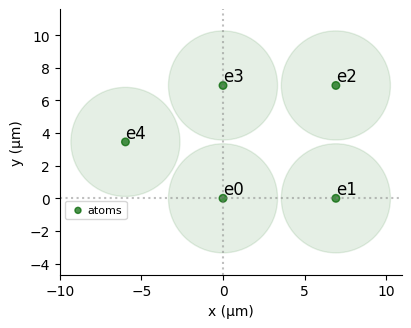

Coordenadas optimizadas:
[[-3.55129189e-05  7.24275553e-05]
 [ 6.91430277e+00  7.39663078e-05]
 [ 6.91438942e+00  6.91424974e+00]
 [ 5.46212186e-05  6.91406736e+00]
 [-5.97776264e+00  3.45714784e+00]]


-5977762.639717151 6914389.418791373 72.4275553447369 6914249.737872701


A=50, B=25.0, C=7.5  →  P(éxito) = 95.70%
  Soluciones válidas: ['00101', '01001', '01010', '10100']  (E = -110.000)
  Conteos solución:   9570 / 10000


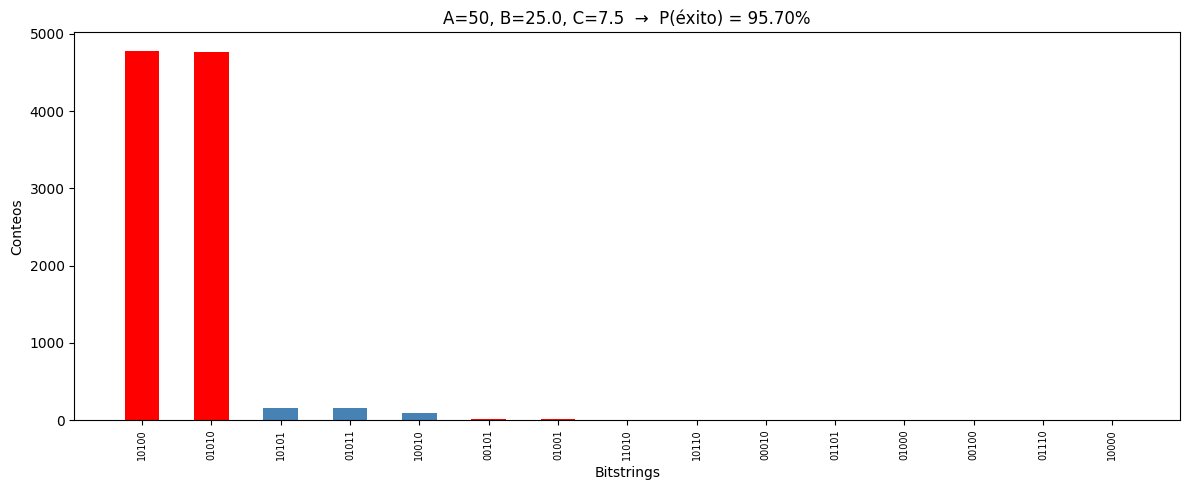

In [126]:
for k in [0.95]:
    A = A_solucion = 50#= 50 #= 10
    B = B_solucion = 0.5*A_solucion #= k*A_solucion#= 0.4*A_solucion
    C = C_solucion = 0.15*A_solucion #= 0.2*A_solucion #= 0.2*A_solucion

    sort_zipped = resolucion_clasica(Q_exacta = Q_exacta_func(A_solucion, B_solucion, C_solucion), print_resultados=True)

    Q       = Q_func(A, B, C)
    geometria, _       = construir_geometria(Q, plot=True, x0_func=x0_func_C4mod) #, x0_func=x0_func_P6mod)
    prob, _            = resolver_qubo(Q, geometria, sort_zipped, A, B, C, plot=True, n_shots=10000)

    A_values = [A]
    B_values = [B]
    C_values = [C]



# Barrido en A para varios grafos

In [68]:
# Barrido en A para varios grafos
# Mantenemos B/A y C/A fijos en valores razonables (Lucas 2014: B/A ~ 0.5, C/A ~ 0.2)
from scipy.optimize import curve_fit

def modelo_exp(A, P_inf, tau):
    return P_inf * (1.0 - np.exp(-A / tau))


ratio_B = 0.5
ratio_C = 0.2

# Para los grafos a estudiar: {nombre: (Q_func, Q_exacta_func, x0_func)}
# Antes de correr cada grafo, asegurar de tener cargada su celda correspondiente

A_values = np.arange(0.01, 105, 8)  # 5, 10, ..., 100 rad/µs
n_repeticiones = 3  # Para promediar fluctuaciones estadísticas

resultados_A = {}  # {(grafo, A): [prob_1, prob_2, ...]}
tiempos_A = {}  # {(grafo, A): [t_1, t_2, ...]}

Q_func_g = Q_func
Q_exacta_func_g = Q_exacta_func

grafos = {
    "P3": (Q_func_P3, Q_exacta_func_P3, x0_func_P3),
    "P4": (Q_func_P4, Q_exacta_func_P4, x0_func_P4),
    "P5": (Q_func_P5, Q_exacta_func_P5, x0_func_P5),
#    "P5 modificado": (Q_func_P5mod, Q_exacta_func_P5mod, x0_func_P5mod),  # Este sale bien pero me da pereza explicarlo
    "P6": (Q_func_P6, Q_exacta_func_P6, x0_func_P6),
#    "P7": (Q_func_P7, Q_exacta_func_P7, x0_func_P7),
#    "P8": (Q_func_P8, Q_exacta_func_P8, x0_func_P8),
#    "P9": (Q_func_P9, Q_exacta_func_P9, x0_func_P9)
#    "P6 modificado": (Q_func_P6mod, Q_exacta_func_P6mod, x0_func_P6mod),  # Este sale con menos probabilidad
#    "Y": (Q_func_Y, Q_exacta_func_Y, x0_func_Y_horizontal),
#    "C4": (Q_func_C4, Q_exacta_func_C4, x0_func_C4),
    "C5": (Q_func_C5, Q_exacta_func_C5, x0_func_C5),
    "C6": (Q_func_C6, Q_exacta_func_C6, x0_func_C6),      # Sale mal por alguna razón
#    "K_": (Q_func_K_13, Q_exacta_func_K_13, x0_func_K13),
}



for nombre, (Q_func_g, Q_exacta_func_g, x0_func_g) in grafos.items():
    inicio_grafo = time.time()
    for A in A_values:
        B = ratio_B * A
        C = ratio_C * A
        
        Q = Q_func_g(A, B, C)
        Q_exacta = Q_exacta_func_g(A, B, C)
        
        diag = -np.diag(Q)
        if np.any(diag <= 0):
            resultados_A[(nombre, A)] = [np.nan]
            tiempos_A[(nombre, A)] = [np.nan]
            continue
        
        sort_zipped = resolucion_clasica(Q_exacta)
        
        probs = []
        tiempos = []
        for rep in range(n_repeticiones):
            try:
                t0 = time.time()
                geometria, _ = construir_geometria(Q, seed=rep, plot=False, x0_func=x0_func_g)
                prob, _ = resolver_qubo(Q, geometria, sort_zipped, A, B, C, sweep_time=11,
                                        plot=False, n_shots=1000)
                t1 = time.time()
                probs.append(prob)
                tiempos.append(t1 - t0)
            except RuntimeError as e:
                print(f"  A={A}, rep={rep}: {e}")
                probs.append(np.nan)
                tiempos.append(np.nan)
        
        resultados_A[(nombre, A)] = probs
        tiempos_A[(nombre, A)] = tiempos

    fin_grafo = time.time()
    print(f"\n=== El grafo {nombre} ha tardado en ejecutarse {fin_grafo - inicio_grafo:.2f} segundos ===")


=== El grafo P3 ha tardado en ejecutarse 5.31 segundos ===

=== El grafo P4 ha tardado en ejecutarse 6.91 segundos ===

=== El grafo P5 ha tardado en ejecutarse 10.35 segundos ===

=== El grafo P6 ha tardado en ejecutarse 13.60 segundos ===

=== El grafo C5 ha tardado en ejecutarse 17.49 segundos ===

=== El grafo C6 ha tardado en ejecutarse 22.61 segundos ===


  P3: R²=0.9720, R²_adj=0.9669, χ²_red=102.02
  P4: R²=0.9969, R²_adj=0.9963, χ²_red=6.12
  P5: R²=0.9785, R²_adj=0.9746, χ²_red=62.13
  P6: R²=0.7168, R²_adj=0.6653, χ²_red=6197.39
  C5: R²=0.9721, R²_adj=0.9670, χ²_red=78.65
  C6: R²=0.9935, R²_adj=0.9923, χ²_red=4.72


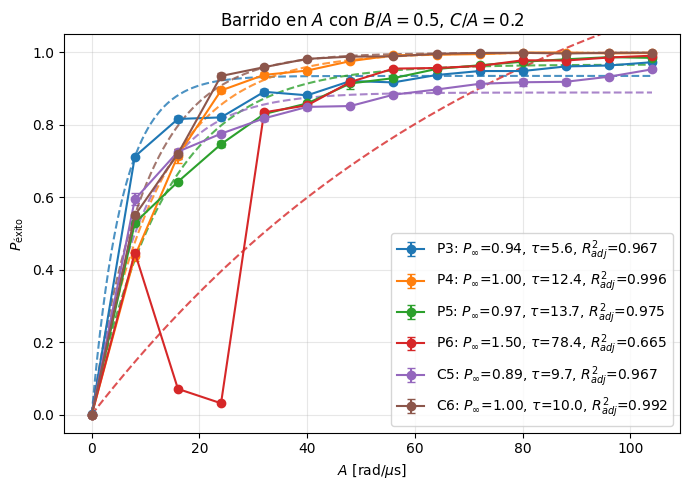

In [70]:
plt.figure(figsize=(7, 5))
A_fino = np.linspace(0, A_values.max(), 400)   # malla densa para dibujar el ajuste
ajustes = {}                                    # guardamos (popt, perr, R2, chi2_red) por grafo

for nombre in grafos.keys():
    medias = np.array([np.nanmean(resultados_A[(nombre, A)]) for A in A_values])
    stds   = np.array([np.nanstd(resultados_A[(nombre, A)])  for A in A_values])

    # Filtramos NaN antes de ajustar
    mask = ~np.isnan(medias)
    A_fit, y_fit, s_fit = A_values[mask], medias[mask], stds[mask]
    # Evitamos sigma=0 (rompe curve_fit con absolute_sigma=True)
    s_pos = s_fit[s_fit > 0]
    s_fit = np.where(s_fit > 0, s_fit, np.nanmean(s_pos) if s_pos.size > 0 else 1e-3)

    # Ajuste con (0,0) impuesto por la forma del modelo
    popt = None
    etiqueta = nombre
    try:
        popt, pcov = curve_fit(
            modelo_exp, A_fit, y_fit,
            p0=[1.0, 20.0],                 # estimación inicial: satura en 1, tau ~ 20
            sigma=s_fit, absolute_sigma=True,
            bounds=([0, 1e-3], [1.5, 1e4]),
            maxfev=10000,
        )
        perr = np.sqrt(np.diag(pcov))

        # --- Bondad del ajuste ---
        y_pred = modelo_exp(A_fit, *popt)
        residuos = y_fit - y_pred
        ss_res = np.sum(residuos**2)
        ss_tot = np.sum((y_fit - np.mean(y_fit))**2)
        R2 = 1 - ss_res / ss_tot if ss_tot > 0 else np.nan
        n, k = len(y_fit), len(popt)
        R2_adj = 1 - (1 - R2) * (n - 1) / (n - k - 1) if (n - k - 1) > 0 else np.nan
        dof = max(n - k, 1)
        chi2_red = np.sum((residuos / s_fit)**2) / dof

        ajustes[nombre] = (popt, perr, R2_adj, chi2_red)
        etiqueta = (rf'{nombre}: $P_\infty$={popt[0]:.2f}, '
                    rf'$\tau$={popt[1]:.1f}, $R^2_{{adj}}$={R2_adj:.3f}')
        print(f'  {nombre}: R²={R2:.4f}, R²_adj={R2_adj:.4f}, χ²_red={chi2_red:.2f}')
    except (RuntimeError, ValueError) as e:
        print(f'Ajuste falló para {nombre}: {e}')

    line = plt.errorbar(A_values, medias, yerr=stds, marker='o', capsize=3, label=etiqueta)
    if popt is not None:
        plt.plot(A_fino, modelo_exp(A_fino, *popt),
                 '--', color=line[0].get_color(), alpha=0.8)

plt.xlabel(r'$A$ [rad/$\mu$s]')
plt.ylabel(r'$P_\text{éxito}$')
plt.title(rf'Barrido en $A$ con $B/A={ratio_B}$, $C/A={ratio_C}$')
plt.legend()
plt.grid(alpha=0.3)
plt.ylim(-0.05, 1.05)
plt.tight_layout()
plt.savefig("barrido_A.png", dpi=200, bbox_inches='tight')
plt.show()

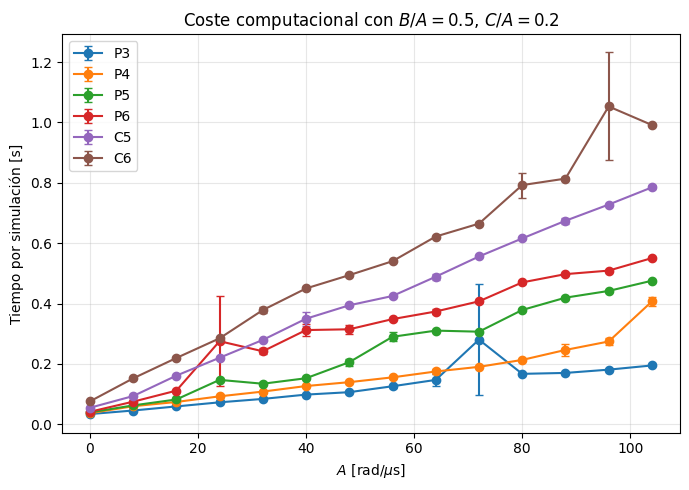

In [69]:
plt.figure(figsize=(7, 5))
for nombre in grafos.keys():
    medias = [np.nanmean(tiempos_A[(nombre, A)]) for A in A_values]
    stds   = [np.nanstd(tiempos_A[(nombre, A)])  for A in A_values]
    plt.errorbar(A_values, medias, yerr=stds, marker='o', label=nombre, capsize=3)

plt.xlabel(r'$A$ [rad/$\mu$s]')
plt.ylabel('Tiempo por simulación [s]')
plt.title(rf'Coste computacional con $B/A={ratio_B}$, $C/A={ratio_C}$')
plt.legend()
plt.grid(alpha=0.3)
#plt.yscale('log')  # Recomendado: el coste crece rápido con A (rigidez del solver)
plt.tight_layout()
plt.savefig("barrido_A_tiempos.png", dpi=200, bbox_inches='tight')
plt.show()

# Heatmap variación B,C

---Solución clásica: 
 [('00101', np.float64(-110.0)), ('01001', np.float64(-110.0)), ('01010', np.float64(-110.0)), ('10100', np.float64(-110.0)), ('00010', np.float64(-92.5)), ('10000', np.float64(-92.5))] 

A=50: 508.44 s


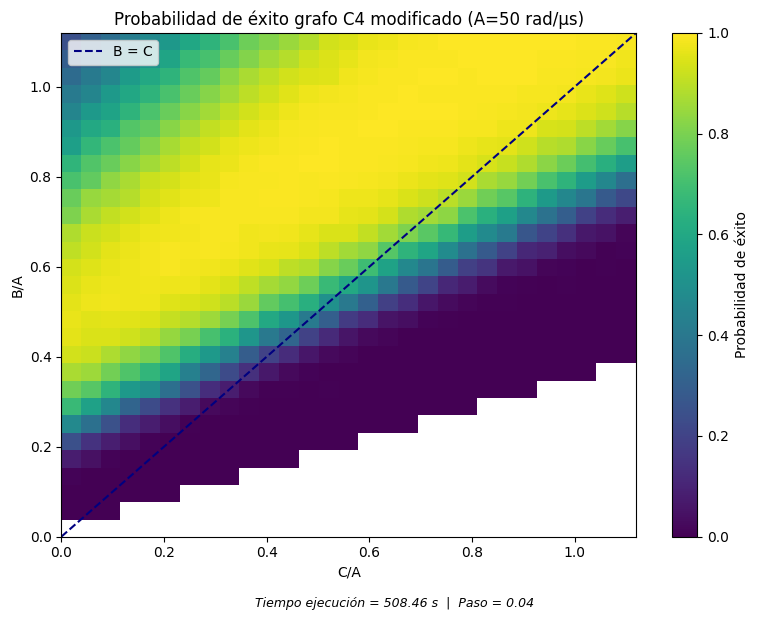

In [127]:
A = A_solucion #10
B = B_solucion #0.5*A
C = C_solucion #0.8*B
x0_func=x0_func_C4mod


sort_zipped = resolucion_clasica(Q_exacta = Q_exacta_func(A_solucion, B_solucion, C_solucion), print_resultados=True)



A_values = [50]
#A_values = np.arange(5, 5.1, 0.5)

resultados = {}
# He cambiado a continuación A por n_shots. Antes tenía n_shots=1000
for A in A_values:
    #B_values = np.arange(0.37*A, 0.42*A, 0.02*A)
    #C_values = np.arange(0.01*A, 0.5*A, 0.02*A)
    #    
    #B_values = np.arange(0.01*A, 1.12*A, 0.08*A)
    #C_values = np.arange(0.01*A, 1.12*A, 0.08*A)

    paso = 0.04
    B_values = np.arange(0*A, 1.12*A, paso*A)
    C_values = np.arange(0*A, 1.12*A, paso*A)

    t0 = time.time() # Para medir el tiempo de ejecución

    for B in B_values:
        for C in C_values:
            Q = Q_func(A, B, C)
            diag = -np.diag(Q)
            
            # Filtro para evitar casoscon detuning negativo
            if np.any(diag <= 0):
                resultados[(A, B, C)] = np.nan
                continue
            try:
                geometria, _ = construir_geometria(Q, plot=False, x0_func=x0_func)
                prob, _ = resolver_qubo(Q, geometria, sort_zipped, A, B, C, plot=False, n_shots=2000)
                resultados[(A, B, C)] = prob
            except Exception:
                # Si la parametrización genera un ValidationError en Bloqade por física inválida,
                # se asigna NaN y el barrido continúa con el siguiente punto.
                resultados[(A, B, C)] = np.nan

            #geometria, _ = construir_geometria(Q, plot=False, x0_func=x0_func)
            #prob, _ = resolver_qubo(Q, geometria, sort_zipped, A, B, C, plot=False, n_shots=2000)
            #resultados[(A, B, C)] = prob



    B_unique = sorted(set(k[1] for k in resultados if k[0] == A))
    C_unique = sorted(set(k[2] for k in resultados if k[0] == A))
    malla = np.array([[resultados[(A, B, C)] for C in C_unique] for B in B_unique])
    malla_masked = np.ma.masked_invalid(malla)

    # Normalizar: B/A y C/B_ref (donde B_ref = 0.5*A como en la definición inicial)
    B_norm = [b / A for b in B_unique]
    C_norm = [c / A for c in C_unique] 

    print(f"A={A}: {time.time() - t0:.2f} s") # Para medir el tiempo de ejecución

    plt.figure(figsize=(8, 6))
    plt.imshow(malla_masked, origin='lower', aspect='auto',
               extent=[C_norm[0], C_norm[-1], B_norm[0], B_norm[-1]], #Esto define los límites de los ejes 
               vmin=0, vmax=1)
    plt.colorbar(label='Probabilidad de éxito')
    plt.xlabel('C/A')
    plt.ylabel('B/A')
    plt.title(f'Probabilidad de éxito grafo {nombre_grafo} (A={A} rad/µs)')

    # Línea B = C (en unidades normalizadas B/A = C/A)
    x_line = np.linspace(C_norm[0], C_norm[-1], 100)
    plt.plot(x_line, x_line, color='navy', linestyle='--', linewidth=1.5, label='B = C')
    plt.figtext(0.5, -0.02,
            f"Tiempo ejecución = {time.time() - t0:.2f} s  |  Paso = {paso:.2f}",
            ha='center', fontsize=9, style='italic')
    plt.legend()
    #plt.savefig(f"mapa_exito_{nombre_grafo} A_{A:.1f}.png")

    plt.tight_layout()
    plt.show()